Backend:        mip
Incidents:      9
Defenders:      7
Matches made:   6

Matched pairs (incident → defender):
  I0 → D2 | benefit=25, cost=8, net=17
  I1 → D1 | benefit=16, cost=1, net=15
  I2 → D4 | benefit=25, cost=4, net=21
  I3 → D0 | benefit=28, cost=9, net=19
  I4 → D5 | benefit=24, cost=9, net=15
  I5 → D3 | benefit=23, cost=5, net=18

Total utility: 105


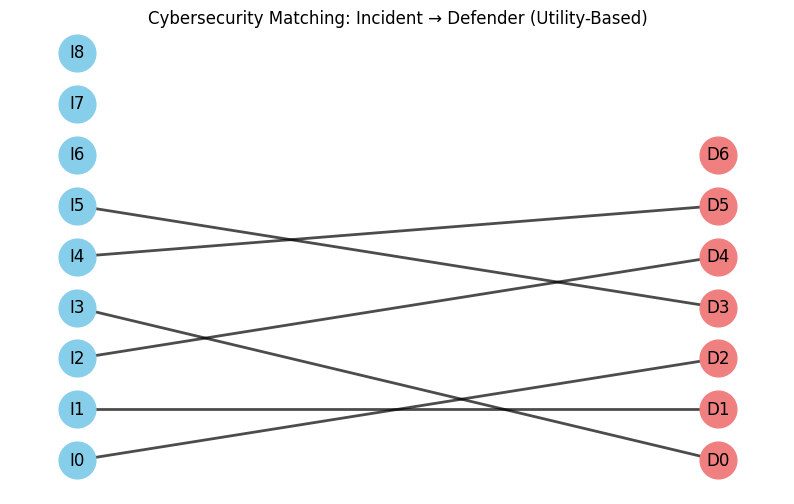

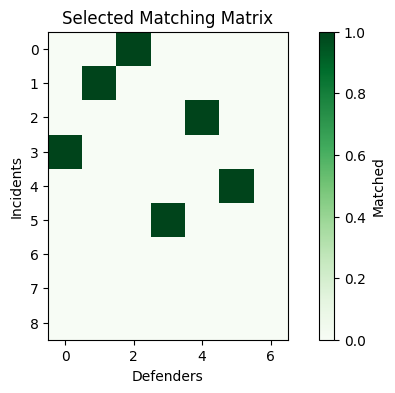

In [3]:
# Matching Problem — Cybersecurity Incident Response Allocation
# --------------------------------------------------------------
# Select optimal incident-response pairs using utility maximization:
# utility = benefit - cost
# Ensures non-trivial solutions and realistic SOC prioritization.

from optilab.aliases import Model, GRB, quicksum
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------------------------------------------------------
# Model
# -------------------------------------------------------------------------------
m = Model()

# -------------------------------------------------------------------------------
# Problem data (SOC system)
# -------------------------------------------------------------------------------
rng = np.random.default_rng(19)

n_incidents = rng.integers(6, 12)
n_defenders = rng.integers(5, 10)

# -------------------------------------------------------------------------------
# Cost: response effort / delay / workload
# -------------------------------------------------------------------------------
cost = rng.integers(1, 20, size=(n_incidents, n_defenders))

# -------------------------------------------------------------------------------
# Benefit: mitigation effectiveness / threat severity reduction
# -------------------------------------------------------------------------------
benefit = rng.integers(5, 30, size=(n_incidents, n_defenders))

# -------------------------------------------------------------------------------
# Feasibility graph (allowed response links)
# -------------------------------------------------------------------------------
feasible = rng.integers(0, 2, size=(n_incidents, n_defenders))

# Ensure connectivity (no isolated rows/cols)
for i in range(n_incidents):
    if feasible[i].sum() == 0:
        j = rng.integers(0, n_defenders)
        feasible[i, j] = 1

for j in range(n_defenders):
    if feasible[:, j].sum() == 0:
        i = rng.integers(0, n_incidents)
        feasible[i, j] = 1

# -------------------------------------------------------------------------------
# Decision variables (ONLY feasible edges)
# -------------------------------------------------------------------------------
x = {}
for i in range(n_incidents):
    for j in range(n_defenders):
        if feasible[i, j] == 1:
            x[i, j] = m.add_binary_var(name=f"x_{i}_{j}")

# -------------------------------------------------------------------------------
# Objective: maximize net utility (benefit - cost)
# -------------------------------------------------------------------------------
m.set_objective(
    quicksum((benefit[i, j] - cost[i, j]) * x[i, j] for (i, j) in x),
    GRB.MAXIMIZE
)

# -------------------------------------------------------------------------------
# Matching constraints (non-overlap structure)
# -------------------------------------------------------------------------------

# Each incident matched at most once
for i in range(n_incidents):
    m.add_constraint(
        quicksum(x[i, j] for j in range(n_defenders) if (i, j) in x)
        <= 1
    )

# Each defender handles at most one incident
for j in range(n_defenders):
    m.add_constraint(
        quicksum(x[i, j] for i in range(n_incidents) if (i, j) in x)
        <= 1
    )

# -------------------------------------------------------------------------------
# Solve
# -------------------------------------------------------------------------------
m.solve()

# -------------------------------------------------------------------------------
# Extract solution
# -------------------------------------------------------------------------------
solution_pairs = [(i, j) for (i, j) in x if x[i, j].x > 0.5]

# -------------------------------------------------------------------------------
# Diagnostics
# -------------------------------------------------------------------------------
print(f"Backend:        {m.backend_name}")
print(f"Incidents:      {n_incidents}")
print(f"Defenders:      {n_defenders}")
print(f"Matches made:   {len(solution_pairs)}")
print()

print("Matched pairs (incident → defender):")
for i, j in solution_pairs:
    print(
        f"  I{i} → D{j} | "
        f"benefit={benefit[i,j]}, cost={cost[i,j]}, "
        f"net={benefit[i,j]-cost[i,j]}"
    )

total_utility = sum(
    benefit[i, j] - cost[i, j] for i, j in solution_pairs
)

print(f"\nTotal utility: {total_utility}")

# -------------------------------------------------------------------------------
# Build solution matrix
# -------------------------------------------------------------------------------
solution_matrix = np.zeros((n_incidents, n_defenders))
for i, j in solution_pairs:
    solution_matrix[i, j] = 1

# -------------------------------------------------------------------------------
# Visualization (graph view)
# -------------------------------------------------------------------------------
B = nx.Graph()

incidents = range(n_incidents)
defenders = range(n_defenders)

B.add_nodes_from(incidents, bipartite=0)
B.add_nodes_from([n_incidents + j for j in defenders], bipartite=1)

for i, j in solution_pairs:
    B.add_edge(i, n_incidents + j)

pos = {}
pos.update((i, (0, i)) for i in incidents)
pos.update((n_incidents + j, (4, j)) for j in defenders)

plt.figure(figsize=(10, 6))

nx.draw_networkx_nodes(
    B, pos,
    nodelist=list(incidents),
    node_color="skyblue",
    node_size=700
)

nx.draw_networkx_nodes(
    B, pos,
    nodelist=[n_incidents + j for j in defenders],
    node_color="lightcoral",
    node_size=700
)

nx.draw_networkx_edges(B, pos, width=2, alpha=0.7)

labels = {i: f"I{i}" for i in incidents}
labels.update({n_incidents + j: f"D{j}" for j in defenders})

nx.draw_networkx_labels(B, pos, labels=labels)

plt.title("Cybersecurity Matching: Incident → Defender (Utility-Based)")
plt.axis("off")
plt.show()

# -------------------------------------------------------------------------------
# Heatmap view
# -------------------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.imshow(solution_matrix, cmap="Greens")
plt.title("Selected Matching Matrix")
plt.xlabel("Defenders")
plt.ylabel("Incidents")
plt.colorbar(label="Matched")
plt.show()